# EDA Pipeline for Financial Social Media Discussions

A **self-contained, portable** notebook for exploratory data analysis of stock-related social media discussion datasets.

This notebook performs:
1. **Data Loading** — auto-detect CSV format, columns, and schema
2. **Ticker Extraction** — identify stock ticker mentions from text
3. **Data Quality Analysis** — missing values, temporal coverage, engagement stats
4. **Sentiment Analysis** — polarity scoring and reliability assessment
5. **Surge / Anomaly Detection** — identify unusual engagement+sentiment spikes
6. **Visualization** — inline charts for distributions and trends
7. **Summary & Recommendation** — dataset suitability scoring

---

## Prerequisites

```bash
pip install pandas numpy matplotlib seaborn textblob vaderSentiment
```

No external package imports beyond these standard data science libraries are required.
This notebook has **zero dependency** on any project-specific `src/` package.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP — Install dependencies (uncomment if needed)
# ══════════════════════════════════════════════════════════════════════════════
# !pip install pandas numpy matplotlib seaborn textblob vaderSentiment

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

import csv
import logging
import os
import re
from dataclasses import dataclass, field
from itertools import product
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Edit these to match your dataset
# ══════════════════════════════════════════════════════════════════════════════

DATA_PATH = r"d:\git\ds-eda-fin-discussions\data\StockMarket_subreddit.csv"

# Column names (set to None for auto-detection)
DATE_COL = None
TEXT_COL = None
TICKER_COL = None
SENTIMENT_COL = None
ENGAGEMENT_COLS = None

# Surge detection thresholds
SURGE_PERCENTILES = [0.90, 0.95, 0.99]
SURGE_STD_DEVS = [0.5, 1.0, 1.5]
SURGE_WINDOW_HOURS = 24
MIN_POSITIVE_CLASS_PCT = 0.02

# Output
OUTPUT_DIR = "output"
SAVE_CHARTS = True


---

## 1. Data Loading

Loads CSV data with auto-detected delimiter and performs column detection for dates, text, engagement metrics, sentiment, and tickers.

In [4]:
# ─── Data Loading Utilities ────────────────────────────────────────────────

def detect_delimiter(filepath: str, sample_size: int = 8192) -> str:
    """Detect the delimiter used in a CSV file by sniffing a sample."""
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            sample = f.read(sample_size)
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
        return dialect.delimiter
    except csv.Error:
        return ","


def load_dataset(filepath: str) -> pd.DataFrame:
    """Load a CSV dataset with auto-detected delimiter."""
    sep = detect_delimiter(filepath)
    print(f"Loading '{filepath}' with delimiter: {repr(sep)}")
    return pd.read_csv(filepath, sep=sep, engine="python", on_bad_lines="warn")


def detect_date_column(df: pd.DataFrame) -> Optional[str]:
    """Detect the most likely date/timestamp column."""
    date_keywords = ["date", "timestamp", "created_at", "created_utc", "time", "posted_at"]

    # Check columns already typed as datetime
    datetime_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if len(datetime_cols) == 1:
        return datetime_cols[0]
    if len(datetime_cols) > 1:
        for col in datetime_cols:
            if any(kw in col.lower() for kw in ["date", "time"]):
                return col
        return datetime_cols[0]

    # Name-based keyword matching
    for col in df.columns:
        if col.lower() in date_keywords:
            return col
    for col in df.columns:
        if any(kw in col.lower() for kw in ["date", "time"]):
            return col

    # Dtype probe — try parsing object/string columns
    for col in df.select_dtypes(include=["object", "string"]).columns:
        sample = df[col].dropna().head(20)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
        if parsed.notna().sum() >= len(sample) * 0.8:
            return col

    return None


def detect_engagement_columns(df: pd.DataFrame) -> list:
    """Detect engagement metric columns."""
    engagement_keywords = {
        "likes", "retweets", "comments", "upvotes", "shares",
        "favorites", "score", "num_comments", "comment_count",
        "like_count", "retweet_count", "ups", "downs",
    }
    return [col for col in df.columns if col.lower() in engagement_keywords]


def detect_text_column(df: pd.DataFrame) -> Optional[str]:
    """Detect the most likely text content column."""
    text_keywords = ["text", "body", "content", "title", "selftext", "comment", "message"]
    for col in df.columns:
        if col.lower() in text_keywords:
            return col
    return None


def detect_sentiment_column(df: pd.DataFrame) -> Optional[str]:
    """Detect the most likely sentiment column."""
    sentiment_keywords = ["sentiment", "polarity", "sentiment_score", "compound", "bullish", "bearish"]
    for col in df.columns:
        if col.lower() in sentiment_keywords:
            return col
    return None


def compute_sentiment_column(df: pd.DataFrame, text_col: str) -> Optional[str]:
    """Compute a sentiment column from text using VADER. Adds 'sentiment' column in-place."""
    try:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        analyzer = SentimentIntensityAnalyzer()
    except ImportError:
        print("WARNING: vaderSentiment not installed. Cannot compute sentiment.")
        return None

    if text_col not in df.columns:
        return None

    texts = df[text_col].fillna("")
    df["sentiment"] = texts.apply(lambda t: analyzer.polarity_scores(str(t))["compound"])
    print(f"Computed sentiment from '{text_col}' column using VADER.")
    return "sentiment"

In [5]:
# ─── Load and Detect Columns ──────────────────────────────────────────────

df = load_dataset(DATA_PATH)
# Sample for faster testing
if len(df) > 500:
    df = df.head(500).copy()
    print(f'Sampled to 500 rows for testing')

# Auto-detect columns (or use user-provided overrides)
date_col = DATE_COL or detect_date_column(df)
text_col = TEXT_COL or detect_text_column(df)
engagement_cols = ENGAGEMENT_COLS or detect_engagement_columns(df)
sentiment_col = SENTIMENT_COL or detect_sentiment_column(df)
ticker_col = TICKER_COL  # Handled in Section 2

# Compute sentiment if not found
if not sentiment_col and text_col:
    sentiment_col = compute_sentiment_column(df, text_col)

print(f'\n{"="*60}')
print(f'Dataset: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'{"="*60}')
print(f'Detected columns:')
print(f'  Date:        {date_col}')
print(f'  Text:        {text_col}')
print(f'  Sentiment:   {sentiment_col}')
print(f'  Engagement:  {engagement_cols}')
print(f'  Ticker:      {ticker_col or "(will extract in Section 2)"}')


Loading 'd:\git\ds-eda-fin-discussions\data\StockMarket_subreddit.csv' with delimiter: ';'


Sampled to 500 rows for testing
Computed sentiment from 'title' column using VADER.

Dataset: d:\git\ds-eda-fin-discussions\data\StockMarket_subreddit.csv
Shape: 500 rows x 9 columns
Detected columns:
  Date:        created_utc
  Text:        title
  Sentiment:   sentiment
  Engagement:  ['score', 'num_comments']
  Ticker:      (will extract in Section 2)


In [6]:
# ─── Preview Data ─────────────────────────────────────────────────────────

print("Data types:")
print(df.dtypes.to_string())
print(f"\nFirst 5 rows:")
df.head()

Data types:
Unnamed: 0        int64
id               object
title            object
url              object
created_utc       int64
score             int64
num_comments      int64
selftext         object
sentiment       float64

First 5 rows:


,Unnamed: 0,id,title,url,created_utc,score,num_comments,selftext,sentiment
0,0,nzc04g,GME Sunday Update w/Marantz Rantz,https://youtu.be/yrW1EPxnmQQ,1623636289,0,0,NaN,0.0000
1,1,nzbyqh,Citadel owns more AMC shares than CLOV!,https://www.reddit.com/r/StockMarket/comments/...,1623636170,1,0,[removed],0.4157
2,2,nzbva7,🚨🚨Marc Cuban invests in Defi project (not clic...,https://youtu.be/_Pfz3tw1oOY,1623635880,0,2,NaN,0.0000
3,3,nzbqht,Why Do Support Lines form on Stock Charts - Te...,https://youtu.be/ZlmitRY7i5g,1623635457,1,1,NaN,0.4019
4,4,nzbhk7,How I should share my information from now on!,https://www.reddit.com/r/StockMarket/comments/...,1623634675,1,0,[removed],0.3595


---

## 2. Ticker Extraction

Identifies stock ticker symbols from text content using:
1. **Cashtag matching** — `$TSLA`, `$AAPL` (high confidence)
2. **Known-ticker matching** — uppercase words matching a curated ticker list

If a ticker column already exists, this section is skipped.

In [7]:
# ─── Ticker Extraction Utilities ──────────────────────────────────────────

# Curated set of common US stock tickers discussed on social media
KNOWN_TICKERS = {
    # Mega-cap / meme stocks
    "AAPL", "MSFT", "GOOGL", "GOOG", "AMZN", "TSLA", "META", "NVDA",
    "AMD", "INTC", "NFLX", "DIS", "PYPL", "SQ", "SHOP", "ROKU",
    # Meme / retail favorites
    "GME", "AMC", "BB", "BBBY", "PLTR", "WISH", "CLOV", "SOFI",
    "SPCE", "NIO", "LCID", "RIVN", "HOOD", "DKNG", "COIN",
    # Finance / banking
    "JPM", "BAC", "GS", "MS", "WFC", "C", "V", "MA",
    # Healthcare / pharma
    "JNJ", "PFE", "MRNA", "BNTX", "ABBV", "UNH", "LLY",
    # Energy
    "XOM", "CVX", "OXY", "BP", "COP",
    # Other large-cap
    "WMT", "COST", "TGT", "HD", "LOW", "NKE", "SBUX",
    "BA", "CAT", "DE", "MMM", "GE", "F", "GM",
    "CRM", "ORCL", "ADBE", "NOW", "SNOW", "UBER", "LYFT",
    "ZM", "DOCU", "CRWD", "NET", "DDOG", "MDB",
    # ETFs
    "SPY", "QQQ", "IWM", "DIA", "ARKK", "VTI", "VOO",
    # Additional retail-popular
    "TWNK", "WKHS", "CLNE", "TTNP", "MVIS", "SENS", "TLRY",
    "SNDL", "CLVS", "RKT", "UWMC", "CRSR", "BNGO",
}

# Common false positives to exclude
_FALSE_POSITIVE_WORDS = {
    "CEO", "IPO", "ETF", "SEC", "FDA", "GDP", "CPI", "ATH", "DD",
    "EPS", "PE", "RSI", "MACD", "OTC", "NYSE", "IMO", "FYI",
    "YOLO", "FOMO", "HODL", "WSB", "OP", "TL", "DR", "TLDR",
    "US", "UK", "EU", "AI", "ML", "IT", "PM", "AM",
    "THE", "AND", "FOR", "ARE", "BUT", "NOT", "YOU", "ALL",
    "CAN", "HER", "WAS", "ONE", "OUR", "OUT", "DAY", "HAD",
    "HAS", "HIS", "HOW", "ITS", "MAY", "NEW", "NOW", "OLD",
    "SEE", "WAY", "WHO", "DID", "GET", "HIM", "LET", "SAY",
    "SHE", "TOO", "USE", "RUN", "BIG", "TOP", "LOW", "HIGH",
    "BUY", "PUT", "CALL", "LONG", "SHORT", "BULL", "BEAR",
    "RED", "GREEN", "MOON", "APE", "APES", "HOLD", "SELL",
}

_CASHTAG_PATTERN = re.compile(r'\$([A-Z]{2,5})\b')
_UPPERCASE_WORD_PATTERN = re.compile(r'\b([A-Z]{2,5})\b')


def extract_tickers_from_text(text: str) -> list:
    """Extract stock ticker symbols from a single text string."""
    if not text or not isinstance(text, str):
        return []

    found_tickers = set()

    # Strategy 1: Cashtag matching ($TICKER)
    for tag in _CASHTAG_PATTERN.findall(text):
        if tag not in _FALSE_POSITIVE_WORDS and len(tag) >= 2:
            found_tickers.add(tag)

    # Strategy 2: Known-ticker matching
    for word in _UPPERCASE_WORD_PATTERN.findall(text):
        if word in KNOWN_TICKERS and word not in _FALSE_POSITIVE_WORDS:
            found_tickers.add(word)

    return sorted(found_tickers)


def add_ticker_column_if_missing(df: pd.DataFrame, ticker_col: str = "ticker",
                                  text_cols: Optional[list] = None) -> pd.DataFrame:
    """Add a ticker column if one doesn't already exist."""
    if ticker_col in df.columns:
        return df

    if text_cols is None:
        candidate_text_cols = ["title", "selftext", "text", "body", "content",
                               "comment", "message", "clean_text", "Text"]
        text_cols = [col for col in candidate_text_cols if col in df.columns]

    result = df.copy()
    if not text_cols:
        result[ticker_col] = "UNKNOWN"
        return result

    def _extract_for_row(row):
        combined = " ".join(str(row[col]) for col in text_cols if pd.notna(row[col]))
        tickers = extract_tickers_from_text(combined)
        return tickers[0] if tickers else "UNKNOWN"

    result[ticker_col] = df.apply(_extract_for_row, axis=1)
    return result

print("Ticker extraction functions defined.")

Ticker extraction functions defined.


In [8]:
# ─── Apply Ticker Extraction ──────────────────────────────────────────────

if ticker_col and ticker_col in df.columns:
    print(f"Ticker column '{ticker_col}' already exists. Skipping extraction.")
else:
    text_cols_for_ticker = [text_col] if text_col else None
    df = add_ticker_column_if_missing(df, ticker_col="ticker", text_cols=text_cols_for_ticker)
    ticker_col = "ticker"

    non_unknown = (df[ticker_col] != "UNKNOWN").sum()
    print(f"Extracted tickers for {non_unknown:,}/{len(df):,} rows ")
    print(f"Unique tickers found: {df[ticker_col][df[ticker_col] != 'UNKNOWN'].nunique()}")

# Show ticker distribution
print(f"\nTop 15 tickers:")
print(df[ticker_col].value_counts().head(15).to_string())

Extracted tickers for 96/500 rows 
Unique tickers found: 37

Top 15 tickers:
ticker
UNKNOWN    404
AMC         26
WISH        13
CLNE         8
WKHS         7
GME          3
TWNK         2
TTNP         2
XL           2
UWMC         2
TSLA         2
RMTI         2
SNDL         2
CRSR         1
PSTH         1


---

## 3. Data Quality Analysis

Analyzes dataset structure, missing values, temporal coverage, and engagement distributions.

In [9]:
# ─── Data Quality Utilities ───────────────────────────────────────────────

def analyze_structure(df: pd.DataFrame, ticker_col: str = "ticker") -> dict:
    """Document dataset structure: schema, types, record count, ticker count."""
    schema = {col: str(dtype) for col, dtype in df.dtypes.items()}
    ticker_count = 0
    if ticker_col in df.columns:
        ticker_count = df[ticker_col].nunique()
    return {
        "schema": schema,
        "record_count": len(df),
        "column_count": len(df.columns),
        "ticker_count": ticker_count,
        "columns": list(df.columns),
    }


def compute_missing_values(df: pd.DataFrame) -> dict:
    """Compute per-column missing value percentages and flag high-risk columns (>30%)."""
    if len(df) == 0:
        return {"missing_percentages": {}, "high_risk_columns": []}
    total_rows = len(df)
    missing_pct = {}
    high_risk = []
    for col in df.columns:
        pct = (df[col].isna().sum() / total_rows) * 100.0
        missing_pct[col] = pct
        if pct > 30.0:
            high_risk.append(col)
    return {"missing_percentages": missing_pct, "high_risk_columns": high_risk}


def analyze_time_coverage(df: pd.DataFrame, date_col: str) -> dict:
    """Analyze time coverage: date range, gaps >7 days, posting frequency."""
    if date_col not in df.columns:
        return {"date_range": ("unknown", "unknown"), "temporal_gaps": [],
                "posting_frequency": {"posts_per_day": 0.0, "total_days": 0}, "gap_count": 0}

    dates = pd.to_datetime(df[date_col], errors="coerce").dropna()
    if len(dates) == 0:
        return {"date_range": ("unknown", "unknown"), "temporal_gaps": [],
                "posting_frequency": {"posts_per_day": 0.0, "total_days": 0}, "gap_count": 0}

    dates_sorted = dates.sort_values().reset_index(drop=True)
    min_date = dates_sorted.iloc[0]
    max_date = dates_sorted.iloc[-1]

    # Find gaps > 7 days
    temporal_gaps = []
    seven_days = pd.Timedelta(days=7)
    for i in range(1, len(dates_sorted)):
        gap = dates_sorted.iloc[i] - dates_sorted.iloc[i - 1]
        if gap > seven_days:
            temporal_gaps.append((
                dates_sorted.iloc[i - 1].strftime("%Y-%m-%d"),
                dates_sorted.iloc[i].strftime("%Y-%m-%d")
            ))

    total_days = (max_date - min_date).days
    posts_per_day = len(dates) / total_days if total_days > 0 else float(len(dates))

    return {
        "date_range": (min_date.strftime("%Y-%m-%d"), max_date.strftime("%Y-%m-%d")),
        "temporal_gaps": temporal_gaps,
        "posting_frequency": {"posts_per_day": posts_per_day, "total_days": total_days},
        "gap_count": len(temporal_gaps),
    }


def compute_engagement_distributions(df: pd.DataFrame, metric_cols: list) -> dict:
    """Compute summary statistics (mean, median, p90, p95, p99) for engagement metrics."""
    results = {}
    for col in metric_cols:
        if col not in df.columns:
            continue
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(series) == 0:
            continue
        results[col] = {
            "mean": float(series.mean()),
            "median": float(series.median()),
            "p90": float(series.quantile(0.90)),
            "p95": float(series.quantile(0.95)),
            "p99": float(series.quantile(0.99)),
        }
    return results

print("Data quality functions defined.")

Data quality functions defined.


In [10]:
# ─── Run Structure Analysis ───────────────────────────────────────────────

structure = analyze_structure(df, ticker_col=ticker_col or "ticker")

print("Dataset Structure")
print("=" * 50)
print(f"Records:  {structure['record_count']:,}")
print(f"Columns:  {structure['column_count']}")
print(f"Tickers:  {structure['ticker_count']} unique")
print(f"\nSchema:")
for col_name, dtype in structure["schema"].items():
    print(f"  {col_name:30s} {dtype}")

Dataset Structure
Records:  500
Columns:  10
Tickers:  38 unique

Schema:
  Unnamed: 0                     int64
  id                             object
  title                          object
  url                            object
  created_utc                    int64
  score                          int64
  num_comments                   int64
  selftext                       object
  sentiment                      float64
  ticker                         object


Missing Values Analysis
      column  missing_pct
    selftext         46.2
  Unnamed: 0          0.0
          id          0.0
       title          0.0
 created_utc          0.0
         url          0.0
       score          0.0
num_comments          0.0
   sentiment          0.0
      ticker          0.0

⚠️  High-risk columns (>30% missing): ['selftext']


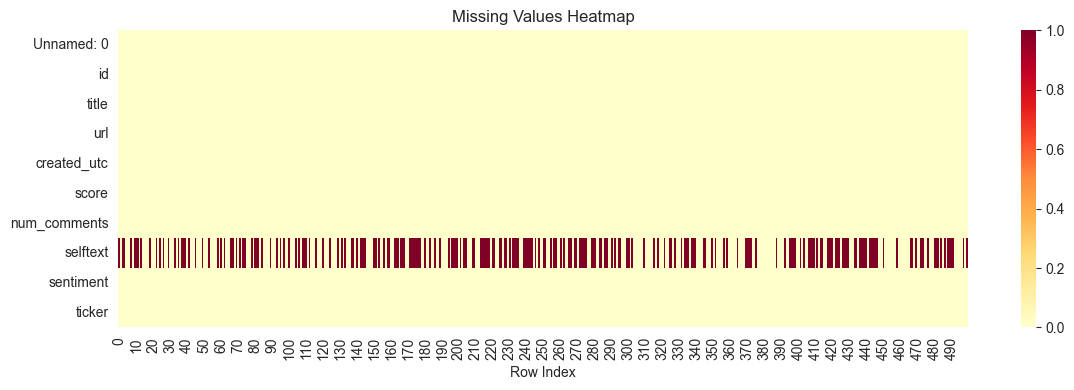

In [11]:
# ─── Missing Values ───────────────────────────────────────────────────────

missing = compute_missing_values(df)

print("Missing Values Analysis")
print("=" * 50)
missing_df = pd.DataFrame([
    {"column": col, "missing_pct": pct}
    for col, pct in missing["missing_percentages"].items()
]).sort_values("missing_pct", ascending=False)

print(missing_df.to_string(index=False))

if missing["high_risk_columns"]:
    print(f"\n⚠️  High-risk columns (>30% missing): {missing['high_risk_columns']}")
else:
    print("\n✓ No high-risk columns (all columns have ≤30% missing)")

# Missing value heatmap
fig, ax = plt.subplots(figsize=(12, max(4, len(df.columns) * 0.3)))
sns.heatmap(df.isna().T, cbar=True, cmap="YlOrRd", yticklabels=True, ax=ax)
ax.set_title("Missing Values Heatmap")
ax.set_xlabel("Row Index")
plt.tight_layout()
plt.show()

In [12]:
# ─── Time Coverage ────────────────────────────────────────────────────────

if date_col:
    time_coverage = analyze_time_coverage(df, date_col)

    print("Time Coverage Analysis")
    print("=" * 50)
    print(f"Date range:      {time_coverage['date_range'][0]} to {time_coverage['date_range'][1]}")
    print(f"Total days:      {time_coverage['posting_frequency']['total_days']}")
    print(f"Posts per day:   {time_coverage['posting_frequency']['posts_per_day']:.1f}")
    print(f"Temporal gaps:   {time_coverage['gap_count']} (gaps > 7 days)")

    if time_coverage["temporal_gaps"]:
        print(f"\nGap details:")
        for start, end in time_coverage["temporal_gaps"][:10]:
            print(f"  {start} → {end}")
        if len(time_coverage["temporal_gaps"]) > 10:
            print(f"  ... and {len(time_coverage['temporal_gaps']) - 10} more")
else:
    time_coverage = None
    print("⚠️  No date column detected. Skipping time coverage analysis.")

Time Coverage Analysis
Date range:      1970-01-01 to 1970-01-01
Total days:      0
Posts per day:   500.0
Temporal gaps:   0 (gaps > 7 days)


In [13]:
# ─── Engagement Distributions ─────────────────────────────────────────────

if engagement_cols:
    engagement_stats = compute_engagement_distributions(df, engagement_cols)

    print("Engagement Distributions")
    print("=" * 50)
    for metric, stats in engagement_stats.items():
        print(f"\n  {metric}:")
        print(f"    Mean:   {stats['mean']:>12,.2f}")
        print(f"    Median: {stats['median']:>12,.2f}")
        print(f"    P90:    {stats['p90']:>12,.2f}")
        print(f"    P95:    {stats['p95']:>12,.2f}")
        print(f"    P99:    {stats['p99']:>12,.2f}")
else:
    engagement_stats = {}
    print("⚠️  No engagement columns detected. Skipping engagement analysis.")

Engagement Distributions

  score:
    Mean:          14.36
    Median:         1.00
    P90:            4.00
    P95:            9.00
    P99:           27.03

  num_comments:
    Mean:           5.79
    Median:         0.00
    P90:            8.00
    P95:           18.10
    P99:          112.43


---

## 4. Sentiment Analysis

Computes sentiment polarity distribution and assesses inter-method agreement between VADER and TextBlob.

In [14]:
# ─── Sentiment Analysis Utilities ─────────────────────────────────────────

def analyze_sentiment(df: pd.DataFrame, text_col: str) -> dict:
    """Sentiment distribution analysis with bullish/bearish ratio."""
    if text_col not in df.columns:
        return {"polarity_scores": {"mean": 0.0, "median": 0.0, "std": 0.0},
                "bullish_count": 0, "bearish_count": 0, "neutral_count": 0,
                "bullish_bearish_ratio": 0.0, "total_analyzed": 0}

    texts = df[text_col].dropna().astype(str)
    if len(texts) == 0:
        return {"polarity_scores": {"mean": 0.0, "median": 0.0, "std": 0.0},
                "bullish_count": 0, "bearish_count": 0, "neutral_count": 0,
                "bullish_bearish_ratio": 0.0, "total_analyzed": 0}

    try:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        analyzer = SentimentIntensityAnalyzer()
    except ImportError:
        print("WARNING: vaderSentiment not installed. Cannot analyze sentiment.")
        return {"polarity_scores": {"mean": 0.0, "median": 0.0, "std": 0.0},
                "bullish_count": 0, "bearish_count": 0, "neutral_count": 0,
                "bullish_bearish_ratio": 0.0, "total_analyzed": 0}

    compound_scores = [analyzer.polarity_scores(t)["compound"] for t in texts]
    scores_arr = np.array(compound_scores)

    bullish = int(np.sum(scores_arr > 0.05))
    bearish = int(np.sum(scores_arr < -0.05))
    neutral = int(len(scores_arr) - bullish - bearish)
    ratio = bullish / bearish if bearish > 0 else (float("inf") if bullish > 0 else 0.0)

    return {
        "polarity_scores": {
            "mean": float(np.mean(scores_arr)),
            "median": float(np.median(scores_arr)),
            "std": float(np.std(scores_arr)),
        },
        "bullish_count": bullish,
        "bearish_count": bearish,
        "neutral_count": neutral,
        "bullish_bearish_ratio": ratio,
        "total_analyzed": len(compound_scores),
    }


def assess_sentiment_reliability(df: pd.DataFrame, text_col: str) -> dict:
    """Compare VADER and TextBlob for inter-method agreement."""
    if text_col not in df.columns:
        return {"agreement_rate": 0.0, "correlation": 0.0, "vader_mean": 0.0,
                "textblob_mean": 0.0, "methods_compared": [], "total_compared": 0}

    texts = df[text_col].dropna().astype(str).tolist()
    if not texts:
        return {"agreement_rate": 0.0, "correlation": 0.0, "vader_mean": 0.0,
                "textblob_mean": 0.0, "methods_compared": [], "total_compared": 0}

    try:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        from textblob import TextBlob
    except ImportError as e:
        print(f"WARNING: Sentiment libraries not available: {e}")
        return {"agreement_rate": 0.0, "correlation": 0.0, "vader_mean": 0.0,
                "textblob_mean": 0.0, "methods_compared": [], "total_compared": 0}

    vader = SentimentIntensityAnalyzer()
    vader_scores = [vader.polarity_scores(t)["compound"] for t in texts]
    textblob_scores = [TextBlob(t).sentiment.polarity for t in texts]

    vader_arr = np.array(vader_scores)
    textblob_arr = np.array(textblob_scores)

    def _polarity_class(score, threshold=0.05):
        if score > threshold: return 1
        elif score < -threshold: return -1
        return 0

    agreements = sum(1 for v, t in zip(vader_scores, textblob_scores)
                     if _polarity_class(v) == _polarity_class(t))
    agreement_rate = agreements / len(texts) if texts else 0.0

    if len(vader_arr) > 1 and np.std(vader_arr) > 0 and np.std(textblob_arr) > 0:
        correlation = float(np.corrcoef(vader_arr, textblob_arr)[0, 1])
    else:
        correlation = 0.0

    return {
        "agreement_rate": agreement_rate,
        "correlation": correlation,
        "vader_mean": float(np.mean(vader_arr)),
        "textblob_mean": float(np.mean(textblob_arr)),
        "methods_compared": ["vader", "textblob"],
        "total_compared": len(texts),
    }

print("Sentiment analysis functions defined.")

Sentiment analysis functions defined.


In [15]:
# ─── Run Sentiment Analysis ───────────────────────────────────────────────

if text_col:
    sentiment_stats = analyze_sentiment(df, text_col)

    print("Sentiment Analysis")
    print("=" * 50)
    print(f"Total analyzed:       {sentiment_stats['total_analyzed']:,}")
    print(f"Bullish (>0.05):      {sentiment_stats['bullish_count']:,}")
    print(f"Bearish (<-0.05):     {sentiment_stats['bearish_count']:,}")
    print(f"Neutral:              {sentiment_stats['neutral_count']:,}")
    print(f"Bullish/Bearish ratio: {sentiment_stats['bullish_bearish_ratio']:.2f}")
    print(f"\nPolarity scores:")
    print(f"  Mean:   {sentiment_stats['polarity_scores']['mean']:.4f}")
    print(f"  Median: {sentiment_stats['polarity_scores']['median']:.4f}")
    print(f"  Std:    {sentiment_stats['polarity_scores']['std']:.4f}")
else:
    sentiment_stats = {}
    print("⚠️  No text column detected. Skipping sentiment analysis.")

Sentiment Analysis
Total analyzed:       500
Bullish (>0.05):      178
Bearish (<-0.05):     56
Neutral:              266
Bullish/Bearish ratio: 3.18

Polarity scores:
  Mean:   0.1384
  Median: 0.0000
  Std:    0.3452


In [16]:
# ─── Sentiment Reliability ────────────────────────────────────────────────

if text_col:
    reliability = assess_sentiment_reliability(df, text_col)

    print("Sentiment Reliability (VADER vs TextBlob)")
    print("=" * 50)
    print(f"Texts compared:    {reliability['total_compared']:,}")
    print(f"Agreement rate:    {reliability['agreement_rate']:.1%}")
    print(f"Correlation:       {reliability['correlation']:.4f}")
    print(f"VADER mean:        {reliability['vader_mean']:.4f}")
    print(f"TextBlob mean:     {reliability['textblob_mean']:.4f}")

    if reliability["agreement_rate"] >= 0.7:
        print("\n✓ Good agreement between methods — sentiment is reliable.")
    elif reliability["agreement_rate"] >= 0.5:
        print("\n⚠️  Moderate agreement — interpret sentiment with caution.")
    else:
        print("\n⚠️  Low agreement — sentiment may not be reliably extracted.")
else:
    reliability = {}
    print("⚠️  No text column. Skipping reliability assessment.")

Sentiment Reliability (VADER vs TextBlob)
Texts compared:    500
Agreement rate:    63.4%
Correlation:       0.4722
VADER mean:        0.1384
TextBlob mean:     0.0735

⚠️  Moderate agreement — interpret sentiment with caution.


---

## 5. Surge / Anomaly Detection

Identifies posts with unusually high engagement combined with significant sentiment shifts.

A **surge** is defined as a post where:
1. Normalized engagement exceeds the configured percentile threshold (per-ticker)
2. Sentiment deviates significantly from the ticker's mean within a 24-hour window

In [17]:
# ─── Surge Analysis Utilities ─────────────────────────────────────────────

@dataclass
class SurgeConfig:
    """Configuration for a surge definition."""
    engagement_percentile: float
    sentiment_std_devs: float
    time_window_hours: int = 24


@dataclass
class SurgeResult:
    """Results from applying a surge definition."""
    config: SurgeConfig
    surge_count: int
    total_posts: int
    surge_percentage: float
    class_imbalance_ratio: float
    is_viable: bool
    timestamp_sufficient: bool = True


def normalize_engagement(df: pd.DataFrame, metric_cols: list, ticker_col: str) -> pd.DataFrame:
    """Normalize engagement metrics per-ticker using z-score."""
    if ticker_col not in df.columns:
        raise ValueError(f"Ticker column '{ticker_col}' not found.")
    missing_cols = [col for col in metric_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Metric columns not found: {missing_cols}")
    if df.empty:
        result = df.copy()
        for col in metric_cols:
            result[f"{col}_normalized"] = pd.Series(dtype="float64")
        return result

    result = df.copy()
    for col in metric_cols:
        grouped = df.groupby(ticker_col)[col]
        ticker_means = grouped.transform("mean")
        ticker_stds = grouped.transform("std", ddof=0)
        normalized = pd.Series(0.0, index=df.index, dtype="float64")
        non_zero_std = ticker_stds > 0
        normalized[non_zero_std] = (
            (df[col][non_zero_std] - ticker_means[non_zero_std]) / ticker_stds[non_zero_std]
        )
        result[f"{col}_normalized"] = normalized
    return result


def check_timestamp_resolution(df: pd.DataFrame, timestamp_col: str) -> dict:
    """Check if timestamps support 24-hour window measurement."""
    if timestamp_col not in df.columns:
        raise ValueError(f"Timestamp column '{timestamp_col}' not found.")
    if df.empty or len(df) < 2:
        return {"sufficient": False, "resolution": "unknown",
                "median_gap_hours": float("nan"), "min_gap_hours": float("nan"),
                "recommendation": "Insufficient data."}

    timestamps = pd.to_datetime(df[timestamp_col])
    sorted_ts = timestamps.sort_values().reset_index(drop=True)
    diffs = sorted_ts.diff().dropna()
    if diffs.empty:
        return {"sufficient": False, "resolution": "unknown",
                "median_gap_hours": float("nan"), "min_gap_hours": float("nan"),
                "recommendation": "Cannot compute time differences."}

    gap_hours = diffs.dt.total_seconds() / 3600.0
    median_gap = float(gap_hours.median())
    min_gap = float(gap_hours.min())

    if min_gap < 1.0 / 60:
        resolution = "seconds"
    elif min_gap < 1.0:
        resolution = "minutes"
    elif min_gap < 24.0:
        resolution = "hours"
    else:
        resolution = "days"

    sufficient = resolution in ("seconds", "minutes", "hours")
    recommendation = (
        f"Resolution ({resolution}) is sufficient. Median gap: {median_gap:.2f}h."
        if sufficient else
        f"Resolution ({resolution}) may be insufficient. Median gap: {median_gap:.2f}h."
    )
    return {"sufficient": sufficient, "resolution": resolution,
            "median_gap_hours": median_gap, "min_gap_hours": min_gap,
            "recommendation": recommendation}


def compute_surge_labels(df: pd.DataFrame, config: SurgeConfig,
                          engagement_cols: list, sentiment_col: str,
                          timestamp_col: str, ticker_col: str) -> pd.Series:
    """Compute binary surge labels for each post."""
    required = engagement_cols + [sentiment_col, timestamp_col, ticker_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Required columns not found: {missing}")
    if df.empty:
        return pd.Series(dtype="bool")

    working_df = df.copy()
    working_df[timestamp_col] = pd.to_datetime(working_df[timestamp_col])

    # Normalize engagement per ticker
    normalized_df = normalize_engagement(working_df, engagement_cols, ticker_col)
    norm_cols = [f"{col}_normalized" for col in engagement_cols]

    # Engagement threshold check
    engagement_exceeds = pd.Series(False, index=df.index)
    for col in norm_cols:
        thresholds = normalized_df.groupby(ticker_col)[col].transform(
            lambda x: x.quantile(config.engagement_percentile)
        )
        engagement_exceeds = engagement_exceeds | (normalized_df[col] >= thresholds)

    # Sentiment shift check
    ticker_sent_mean = working_df.groupby(ticker_col)[sentiment_col].transform("mean")
    ticker_sent_std = working_df.groupby(ticker_col)[sentiment_col].transform(
        lambda x: x.std(ddof=0)
    )
    sentiment_deviation = (working_df[sentiment_col] - ticker_sent_mean).abs()
    non_zero_std = ticker_sent_std > 0
    sentiment_exceeds = non_zero_std & (
        sentiment_deviation > config.sentiment_std_devs * ticker_sent_std
    )

    # Time window constraint
    time_window = pd.Timedelta(hours=config.time_window_hours)
    working_df = working_df.sort_values([ticker_col, timestamp_col])
    same_ticker = working_df[ticker_col] == working_df[ticker_col].shift(1)
    time_diff = working_df[timestamp_col] - working_df[timestamp_col].shift(1)
    has_window_context = (same_ticker & (time_diff <= time_window)).reindex(df.index, fill_value=False)

    return engagement_exceeds & sentiment_exceeds & has_window_context


def evaluate_surge_definitions(df: pd.DataFrame, percentiles: list, std_devs: list,
                                engagement_cols: list, sentiment_col: str,
                                timestamp_col: str, ticker_col: str) -> list:
    """Evaluate multiple surge definitions and report class balance."""
    results = []
    ts_resolution = check_timestamp_resolution(df, timestamp_col)
    timestamp_sufficient = ts_resolution["sufficient"]
    total_posts = len(df)

    for percentile, std_dev in product(percentiles, std_devs):
        config = SurgeConfig(engagement_percentile=percentile,
                             sentiment_std_devs=std_dev, time_window_hours=24)
        surge_labels = compute_surge_labels(
            df, config, engagement_cols, sentiment_col, timestamp_col, ticker_col
        )
        surge_count = int(surge_labels.sum())
        surge_pct = (surge_count / total_posts) * 100.0 if total_posts > 0 else 0.0
        non_surge = total_posts - surge_count
        imbalance = non_surge / surge_count if surge_count > 0 else float("inf")
        is_viable = surge_pct >= (MIN_POSITIVE_CLASS_PCT * 100)

        results.append(SurgeResult(
            config=config, surge_count=surge_count, total_posts=total_posts,
            surge_percentage=surge_pct, class_imbalance_ratio=imbalance,
            is_viable=is_viable, timestamp_sufficient=timestamp_sufficient,
        ))
    return results

print("Surge analysis functions defined.")

Surge analysis functions defined.


In [18]:
# ─── Run Surge Analysis ───────────────────────────────────────────────────

can_run_surge = (engagement_cols and sentiment_col and date_col and ticker_col)

if can_run_surge:
    # Check timestamp resolution first
    ts_check = check_timestamp_resolution(df, date_col)
    print("Timestamp Resolution")
    print("=" * 50)
    print(f"Resolution:     {ts_check['resolution']}")
    print(f"Sufficient:     {ts_check['sufficient']}")
    print(f"Median gap:     {ts_check['median_gap_hours']:.2f} hours")
    print(f"Recommendation: {ts_check['recommendation']}")

    # Evaluate surge definitions
    print(f"\nEvaluating {len(SURGE_PERCENTILES) * len(SURGE_STD_DEVS)} surge definitions...")
    surge_results = evaluate_surge_definitions(
        df, SURGE_PERCENTILES, SURGE_STD_DEVS,
        engagement_cols, sentiment_col, date_col, ticker_col
    )

    # Display results as a table
    print(f"\nSurge Definition Results")
    print("=" * 70)
    surge_table = pd.DataFrame([{
        "Percentile": r.config.engagement_percentile,
        "Std Devs": r.config.sentiment_std_devs,
        "Surge Count": r.surge_count,
        "Surge %": f"{r.surge_percentage:.2f}%",
        "Imbalance Ratio": f"{r.class_imbalance_ratio:.1f}:1" if r.class_imbalance_ratio != float("inf") else "∞:1",
        "Viable": "✓" if r.is_viable else "✗",
    } for r in surge_results])
    print(surge_table.to_string(index=False))

    viable_count = sum(1 for r in surge_results if r.is_viable)
    print(f"\nViable definitions: {viable_count}/{len(surge_results)}")
else:
    surge_results = []
    missing_for_surge = []
    if not engagement_cols: missing_for_surge.append("engagement columns")
    if not sentiment_col: missing_for_surge.append("sentiment column")
    if not date_col: missing_for_surge.append("date column")
    if not ticker_col: missing_for_surge.append("ticker column")
    print(f"⚠️  Cannot run surge analysis. Missing: {', '.join(missing_for_surge)}")

Timestamp Resolution
Resolution:     seconds
Sufficient:     True
Median gap:     0.00 hours
Recommendation: Resolution (seconds) is sufficient. Median gap: 0.00h.

Evaluating 9 surge definitions...



Surge Definition Results
 Percentile  Std Devs  Surge Count Surge % Imbalance Ratio Viable
       0.90       0.5           43   8.60%          10.6:1      ✓
       0.90       1.0           28   5.60%          16.9:1      ✓
       0.90       1.5           17   3.40%          28.4:1      ✓
       0.95       0.5           32   6.40%          14.6:1      ✓
       0.95       1.0           17   3.40%          28.4:1      ✓
       0.95       1.5            8   1.60%          61.5:1      ✗
       0.99       0.5           16   3.20%          30.2:1      ✓
       0.99       1.0            6   1.20%          82.3:1      ✗
       0.99       1.5            4   0.80%         124.0:1      ✗

Viable definitions: 6/9


---

## 6. Visualization

Generates inline charts for engagement distributions, sentiment distributions, and surge frequency.

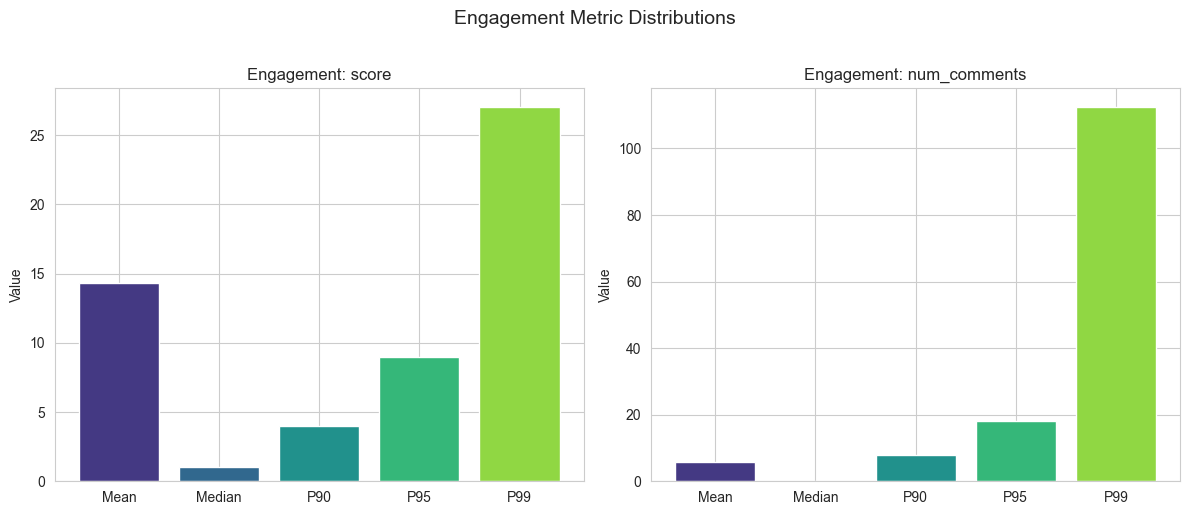

In [19]:
# ─── Engagement Distribution Charts ───────────────────────────────────────

if engagement_stats:
    n_metrics = len(engagement_stats)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 5), squeeze=False)

    for idx, (metric_name, stats) in enumerate(engagement_stats.items()):
        ax = axes[0, idx]
        stat_labels = ["Mean", "Median", "P90", "P95", "P99"]
        stat_values = [stats["mean"], stats["median"], stats["p90"], stats["p95"], stats["p99"]]
        bars = ax.bar(stat_labels, stat_values, color=sns.color_palette("viridis", 5))
        ax.set_title(f"Engagement: {metric_name}", fontsize=12)
        ax.set_ylabel("Value")

    plt.suptitle("Engagement Metric Distributions", fontsize=14, y=1.02)
    plt.tight_layout()
    if SAVE_CHARTS:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        plt.savefig(os.path.join(OUTPUT_DIR, "engagement_distributions.png"), dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("No engagement stats to visualize.")

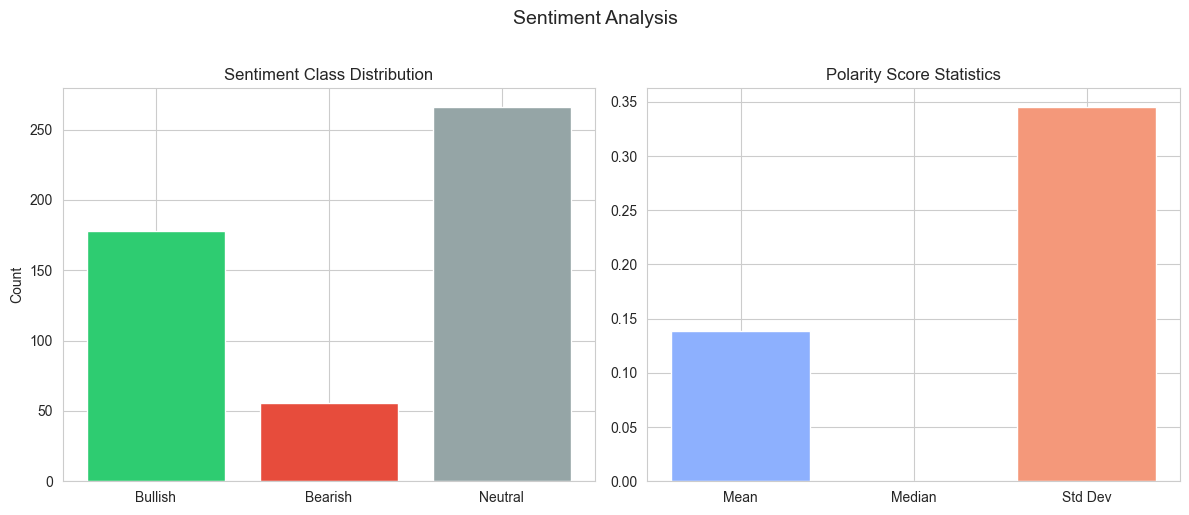

In [20]:
# ─── Sentiment Distribution Charts ────────────────────────────────────────

if sentiment_stats and sentiment_stats.get("total_analyzed", 0) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Chart 1: Sentiment class distribution
    categories = ["Bullish", "Bearish", "Neutral"]
    counts = [sentiment_stats["bullish_count"], sentiment_stats["bearish_count"],
              sentiment_stats["neutral_count"]]
    colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
    ax1.bar(categories, counts, color=colors)
    ax1.set_title("Sentiment Class Distribution")
    ax1.set_ylabel("Count")

    # Chart 2: Polarity score stats
    pol = sentiment_stats["polarity_scores"]
    score_names = ["Mean", "Median", "Std Dev"]
    score_values = [pol["mean"], pol["median"], pol["std"]]
    ax2.bar(score_names, score_values, color=sns.color_palette("coolwarm", 3))
    ax2.set_title("Polarity Score Statistics")
    ax2.axhline(y=0, color="black", linestyle="--", linewidth=0.5)

    plt.suptitle("Sentiment Analysis", fontsize=14, y=1.02)
    plt.tight_layout()
    if SAVE_CHARTS:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_distributions.png"), dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("No sentiment stats to visualize.")

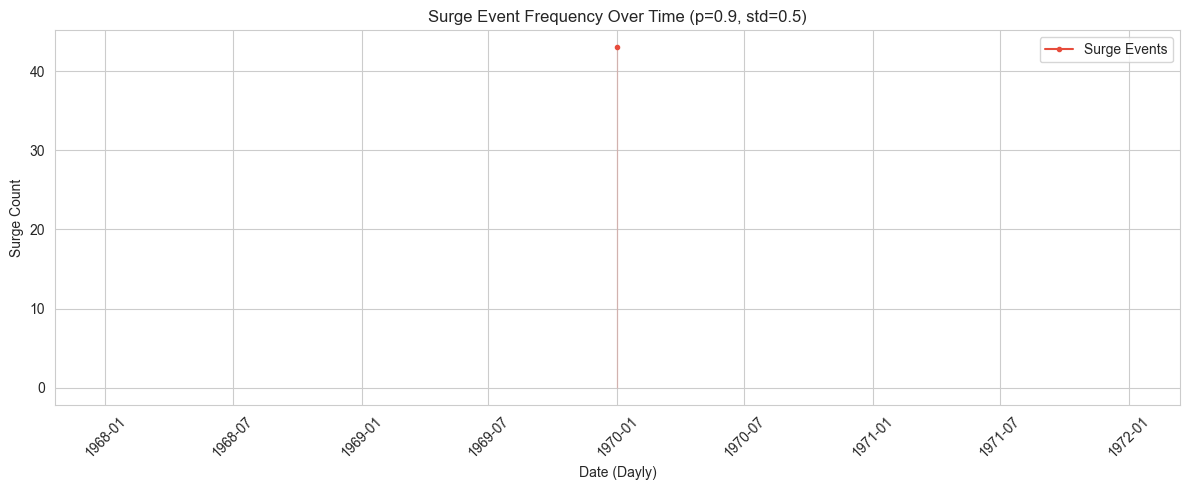

In [21]:
# ─── Surge Frequency Chart ────────────────────────────────────────────────

if can_run_surge and surge_results:
    # Use the most permissive viable config to show surge events over time
    viable_results = [r for r in surge_results if r.is_viable]
    if viable_results:
        best_config = viable_results[0].config  # Most permissive (first viable)
    else:
        best_config = surge_results[0].config  # Use first if none viable

    surge_labels = compute_surge_labels(
        df, best_config, engagement_cols, sentiment_col, date_col, ticker_col
    )
    df["_surge"] = surge_labels

    # Plot surge frequency over time
    surge_df = df[df["_surge"] == True].copy()
    if len(surge_df) > 0 and date_col:
        surge_df[date_col] = pd.to_datetime(surge_df[date_col], errors="coerce")
        surge_df = surge_df.dropna(subset=[date_col])

        date_range = surge_df[date_col].max() - surge_df[date_col].min()
        freq = "W" if date_range.days > 180 else "D"
        freq_label = "Week" if freq == "W" else "Day"

        surge_ts = surge_df.set_index(date_col).resample(freq)["_surge"].count()

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(surge_ts.index, surge_ts.values, color="#e74c3c", linewidth=1.5,
                marker="o", markersize=3, label="Surge Events")
        ax.fill_between(surge_ts.index, surge_ts.values, alpha=0.2, color="#e74c3c")
        ax.set_title(f"Surge Event Frequency Over Time (p={best_config.engagement_percentile}, "
                     f"std={best_config.sentiment_std_devs})")
        ax.set_xlabel(f"Date ({freq_label}ly)")
        ax.set_ylabel("Surge Count")
        ax.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        if SAVE_CHARTS:
            os.makedirs(OUTPUT_DIR, exist_ok=True)
            plt.savefig(os.path.join(OUTPUT_DIR, "surge_frequency.png"), dpi=100, bbox_inches="tight")
        plt.show()
    else:
        print("No surge events detected for visualization.")

    # Clean up temp column
    df.drop(columns=["_surge"], inplace=True, errors="ignore")
else:
    print("Surge analysis not available for visualization.")

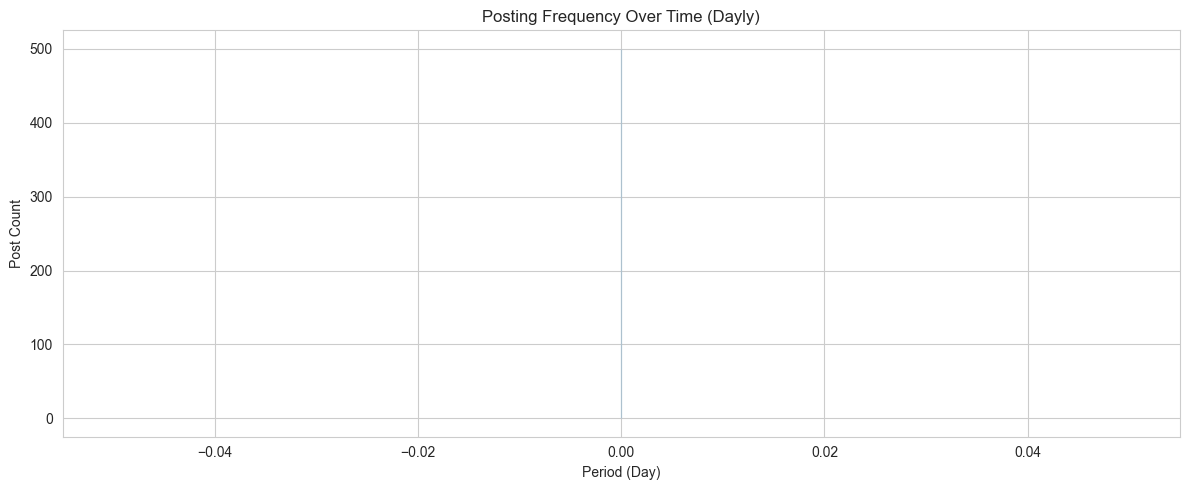

In [22]:
# ─── Posting Frequency Over Time ─────────────────────────────────────────

if date_col:
    dates = pd.to_datetime(df[date_col], errors="coerce").dropna()
    if len(dates) > 0:
        date_range = dates.max() - dates.min()
        freq = "W" if date_range.days > 180 else "D"
        freq_label = "Week" if freq == "W" else "Day"

        post_counts = dates.dt.to_period(freq[0]).value_counts().sort_index()

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(range(len(post_counts)), post_counts.values,
                color="#3498db", linewidth=1.5)
        ax.fill_between(range(len(post_counts)), post_counts.values,
                        alpha=0.2, color="#3498db")
        ax.set_title(f"Posting Frequency Over Time ({freq_label}ly)")
        ax.set_xlabel(f"Period ({freq_label})")
        ax.set_ylabel("Post Count")
        plt.tight_layout()
        if SAVE_CHARTS:
            os.makedirs(OUTPUT_DIR, exist_ok=True)
            plt.savefig(os.path.join(OUTPUT_DIR, "posting_frequency.png"), dpi=100, bbox_inches="tight")
        plt.show()
else:
    print("No date column available for time series chart.")

---

## 7. Risk Catalog

Catalogs data quality issues, biases, temporal leakage risks, and coverage gaps.

In [23]:
# ─── Risk Cataloging ──────────────────────────────────────────────────────

def catalog_risks(df, missing_result=None, time_result=None,
                  date_col="date", ticker_col="ticker") -> list:
    """Catalog data quality issues, biases, and coverage gaps."""
    risks = []

    # High missing columns
    if missing_result and missing_result.get("high_risk_columns"):
        cols = missing_result["high_risk_columns"]
        risks.append(f"High missing data: columns {cols} have >30% missing values.")

    # Small dataset
    if len(df) < 1000:
        risks.append(f"Small dataset ({len(df)} rows): may be insufficient for reliable analysis.")

    # Duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        dup_pct = (dup_count / len(df)) * 100 if len(df) > 0 else 0
        risks.append(f"Duplicate rows: {dup_count} ({dup_pct:.1f}%) may inflate statistics.")

    # Date issues
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], errors="coerce").dropna()
        if len(dates) > 0:
            future_count = (dates > pd.Timestamp.now()).sum()
            if future_count > 0:
                risks.append(f"Future dates: {future_count} rows have dates in the future.")
    else:
        risks.append(f"No date column: temporal analysis cannot be performed.")

    # Temporal gaps
    if time_result and time_result.get("gap_count", 0) > 0:
        risks.append(f"Temporal gaps: {time_result['gap_count']} gaps >7 days detected.")

    # Ticker imbalance
    if ticker_col in df.columns:
        ticker_counts = df[ticker_col].value_counts()
        if "UNKNOWN" in ticker_counts.index:
            ticker_counts = ticker_counts.drop("UNKNOWN")
        if len(ticker_counts) > 1:
            top_pct = (ticker_counts.iloc[0] / len(df)) * 100
            if top_pct > 50:
                risks.append(
                    f"Ticker imbalance: '{ticker_counts.index[0]}' is {top_pct:.1f}% of data."
                )

    # Short time span
    if time_result and time_result.get("posting_frequency"):
        total_days = time_result["posting_frequency"].get("total_days", 0)
        if 0 < total_days < 90:
            risks.append(f"Short time span ({total_days} days): may miss seasonal patterns.")

    return risks


# Run risk catalog
risks = catalog_risks(
    df,
    missing_result=missing,
    time_result=time_coverage if date_col else None,
    date_col=date_col or "date",
    ticker_col=ticker_col or "ticker",
)

print("Risk Catalog")
print("=" * 50)
if risks:
    for i, risk in enumerate(risks, 1):
        print(f"  {i}. {risk}")
else:
    print("  ✓ No significant risks identified.")

Risk Catalog
  1. High missing data: columns ['selftext'] have >30% missing values.
  2. Small dataset (500 rows): may be insufficient for reliable analysis.


---

## 8. Summary & Recommendation

Evaluates overall dataset suitability based on EDA objectives and provides a go/no-go recommendation.

In [24]:
# ─── EDA Objective Evaluation ─────────────────────────────────────────────

def evaluate_eda_objectives(structure, missing, time_cov, engagement_stats,
                            sentiment_stats, text_col, engagement_cols) -> dict:
    """Evaluate EDA objectives and return pass/fail for each."""
    objectives = {}
    objectives["dataset_structure"] = structure.get("record_count", 0) > 0
    objectives["missing_values"] = len(missing.get("missing_percentages", {})) > 0
    objectives["time_coverage"] = (
        time_cov is not None and time_cov.get("date_range", ("unknown",))[0] != "unknown"
    )
    objectives["engagement_distributions"] = len(engagement_stats) > 0
    objectives["sentiment_distributions"] = bool(sentiment_stats) and text_col is not None
    objectives["surge_definitions"] = (
        len(engagement_cols) > 0 and text_col is not None
        and time_cov is not None and time_cov.get("date_range", ("unknown",))[0] != "unknown"
    )
    return objectives


def evaluate_dataset_suitability(objective_results: dict) -> dict:
    """Produce go/no-go recommendation. Unsuitable if 3+ objectives fail."""
    failing = [name for name, passed in objective_results.items() if not passed]
    passing = [name for name, passed in objective_results.items() if passed]
    failure_count = len(failing)
    total = len(objective_results)

    if failure_count >= 3:
        recommendation = "unsuitable"
        justification = (
            f"Dataset is UNSUITABLE: {failure_count}/{total} objectives failed "
            f"(threshold: 3). Failing: {', '.join(failing)}."
        )
    else:
        recommendation = "suitable"
        if failure_count == 0:
            justification = f"Dataset is SUITABLE: all {total} objectives passed."
        else:
            justification = (
                f"Dataset is SUITABLE: only {failure_count}/{total} objectives failed "
                f"(threshold: 3). Failing: {', '.join(failing)}."
            )

    return {
        "recommendation": recommendation,
        "failing_objectives": failing,
        "passing_objectives": passing,
        "total_objectives": total,
        "failure_count": failure_count,
        "justification": justification,
    }

In [25]:
# ─── Run Final Evaluation ─────────────────────────────────────────────────

objectives = evaluate_eda_objectives(
    structure, missing,
    time_coverage if date_col else None,
    engagement_stats,
    sentiment_stats,
    text_col, engagement_cols or []
)

suitability = evaluate_dataset_suitability(objectives)

print("EDA Objectives")
print("=" * 60)
for obj_name, passed in objectives.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}  {obj_name}")

print(f"\n{'='*60}")
print(f"RECOMMENDATION: {suitability['recommendation'].upper()}")
print(f"{'='*60}")
print(suitability["justification"])

if risks:
    print(f"\nRisks to address ({len(risks)}):")
    for risk in risks:
        print(f"  • {risk}")

EDA Objectives
  ✓ PASS  dataset_structure
  ✓ PASS  missing_values
  ✓ PASS  time_coverage
  ✓ PASS  engagement_distributions
  ✓ PASS  sentiment_distributions
  ✓ PASS  surge_definitions

RECOMMENDATION: SUITABLE
Dataset is SUITABLE: all 6 objectives passed.

Risks to address (2):
  • High missing data: columns ['selftext'] have >30% missing values.
  • Small dataset (500 rows): may be insufficient for reliable analysis.


In [26]:
# ─── Summary Report ───────────────────────────────────────────────────────

print("\n" + "═" * 60)
print("              EDA PIPELINE SUMMARY REPORT")
print("═" * 60)
print(f"\nDataset:           {DATA_PATH}")
print(f"Records:           {structure['record_count']:,}")
print(f"Columns:           {structure['column_count']}")
print(f"Unique tickers:    {structure['ticker_count']}")
if date_col and time_coverage:
    print(f"Date range:        {time_coverage['date_range'][0]} to {time_coverage['date_range'][1]}")
    print(f"Posts/day:         {time_coverage['posting_frequency']['posts_per_day']:.1f}")
    print(f"Temporal gaps:     {time_coverage['gap_count']}")
if engagement_cols:
    print(f"Engagement cols:   {engagement_cols}")
if sentiment_stats:
    print(f"Bullish/Bearish:   {sentiment_stats.get('bullish_bearish_ratio', 0):.2f}")
if surge_results:
    viable = sum(1 for r in surge_results if r.is_viable)
    print(f"Surge viable:      {viable}/{len(surge_results)} definitions")
print(f"Risks identified:  {len(risks)}")
print(f"\nFinal verdict:     {suitability['recommendation'].upper()}")
print(f"Passing objectives: {len(suitability['passing_objectives'])}/{suitability['total_objectives']}")
print("═" * 60)


════════════════════════════════════════════════════════════
              EDA PIPELINE SUMMARY REPORT
════════════════════════════════════════════════════════════

Dataset:           d:\git\ds-eda-fin-discussions\data\StockMarket_subreddit.csv
Records:           500
Columns:           10
Unique tickers:    38
Date range:        1970-01-01 to 1970-01-01
Posts/day:         500.0
Temporal gaps:     0
Engagement cols:   ['score', 'num_comments']
Bullish/Bearish:   3.18
Surge viable:      6/9 definitions
Risks identified:  2

Final verdict:     SUITABLE
Passing objectives: 6/6
════════════════════════════════════════════════════════════


---

## Next Steps

Based on the analysis above:

- If **SUITABLE**: proceed with feature engineering and model training
- If **UNSUITABLE**: consider the identified gaps and risks before proceeding

### Common follow-up actions:
- Address high-risk missing columns (imputation or removal)
- Augment short time spans with additional data sources
- Resolve ticker imbalance with stratified sampling
- Fill temporal gaps or adjust surge window accordingly

---

*This notebook is fully portable. Copy it to any project, edit the Configuration cell, and run.*